# TrashNet — Clasificador jerárquico por contenedor con MobileNetV3Small + Optuna

Notebook definitivo del tercer modelo del proyecto.

Este modelo reutiliza exactamente el mismo dataset TrashNet, pero **reasigna las 6 clases originales a 4 destinos de contenedor**:

- `plastic` + `metal` → **amarillo**
- `paper` + `cardboard` → **azul**
- `glass` → **verde**
- `trash` → **gris**

No es necesario duplicar ni mover las imágenes: la reasignación se realiza en código al cargar el dataset.

El notebook compara el modelo con hiperparámetros manuales versus el modelo optimizado con Optuna e incluye accuracy, precision, recall, F1, matrices de confusión, curvas ROC y predicciones.

In [27]:
# 1. Importaciones y configuración general

import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15
N_TRIALS = 10
OPTUNA_EPOCHS = 8

TRAIN_DIR = '../dataset/train'
VALID_DIR = '../dataset/validation'
TEST_DIR = '../dataset/test'
MODEL_DIR = 'modelo_guardado'
os.makedirs(MODEL_DIR, exist_ok=True)

# Clases originales de TrashNet (orden alfabético usado por image_dataset_from_directory)
ORIGINAL_CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Clases finales del modelo jerárquico
CLASSES = ['amarillo', 'azul', 'gris', 'verde']
N_CLASSES = len(CLASSES)

# Mapeo: índice original -> índice del contenedor
# cardboard(0)->azul(1), glass(1)->verde(3), metal(2)->amarillo(0),
# paper(3)->azul(1), plastic(4)->amarillo(0), trash(5)->gris(2)
ORIGINAL_TO_CONTAINER = tf.constant([1, 3, 0, 1, 0, 2], dtype=tf.int32)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))
print('Clases finales:', CLASSES)


TensorFlow: 2.21.0
GPU disponible: []
Clases finales: ['amarillo', 'azul', 'gris', 'verde']


In [28]:
# 2. Validación de la estructura del dataset original

def validar_directorio_dataset(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(f'No existe {nombre}: {ruta}')
    carpetas = sorted([d for d in os.listdir(ruta) if os.path.isdir(os.path.join(ruta, d))])
    print(f'{nombre}: {carpetas}')
    if carpetas != ORIGINAL_CLASSES:
        print('ADVERTENCIA: las carpetas encontradas no coinciden exactamente con ORIGINAL_CLASSES.')

validar_directorio_dataset(TRAIN_DIR, 'TRAIN')
validar_directorio_dataset(VALID_DIR, 'VALIDATION')
validar_directorio_dataset(TEST_DIR, 'TEST')


TRAIN: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
VALIDATION: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
TEST: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [29]:
# 3. Conteo de imágenes por clase original y por contenedor

def contar_imagenes_por_clase(ruta):
    extensiones = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    return {
        clase: sum(
            1 for archivo in os.listdir(os.path.join(ruta, clase))
            if archivo.lower().endswith(extensiones)
        )
        for clase in ORIGINAL_CLASSES
    }

MAPEO_NOMBRE = {
    'cardboard': 'azul',
    'glass': 'verde',
    'metal': 'amarillo',
    'paper': 'azul',
    'plastic': 'amarillo',
    'trash': 'gris'
}

def reagrupar_conteos(conteos_originales):
    agrupados = {clase: 0 for clase in CLASSES}
    for clase_original, cantidad in conteos_originales.items():
        agrupados[MAPEO_NOMBRE[clase_original]] += cantidad
    return agrupados

conteos_train_original = contar_imagenes_por_clase(TRAIN_DIR)
conteos_train = reagrupar_conteos(conteos_train_original)

print('Conteo original:', conteos_train_original)
print('Conteo por contenedor:', conteos_train)


Conteo original: {'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 415, 'plastic': 337, 'trash': 95}
Conteo por contenedor: {'amarillo': 624, 'azul': 697, 'gris': 95, 'verde': 350}


In [30]:
# 4. Pesos de clase para compensar el desbalance después del reagrupamiento

total_train = sum(conteos_train.values())
class_weights = {
    i: total_train / (N_CLASSES * conteos_train[clase])
    for i, clase in enumerate(CLASSES)
}

print('Class weights:')
for i, clase in enumerate(CLASSES):
    print(f'{clase}: {class_weights[i]:.4f}')


Class weights:
amarillo: 0.7075
azul: 0.6334
gris: 4.6474
verde: 1.2614


In [31]:
# 5. Importación del dataset y reasignación automática a colores de contenedor

def cargar_dataset_original(ruta, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        ruta,
        labels='inferred',
        label_mode='int',
        class_names=ORIGINAL_CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None
    )

def remapear_a_contenedores(images, labels):
    nuevas_labels = tf.gather(ORIGINAL_TO_CONTAINER, labels)
    nuevas_labels = tf.one_hot(nuevas_labels, depth=N_CLASSES)
    return images, nuevas_labels

train_raw = cargar_dataset_original(TRAIN_DIR, shuffle=True)
valid_raw = cargar_dataset_original(VALID_DIR, shuffle=False)
test_raw = cargar_dataset_original(TEST_DIR, shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_raw.map(remapear_a_contenedores, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_ds = valid_raw.map(remapear_a_contenedores, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_raw.map(remapear_a_contenedores, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Mapeo utilizado:')
for origen, destino in MAPEO_NOMBRE.items():
    print(f'{origen:10s} -> {destino}')


Found 1766 files belonging to 6 classes.


Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Mapeo utilizado:
cardboard  -> azul
glass      -> verde
metal      -> amarillo
paper      -> azul
plastic    -> amarillo
trash      -> gris


In [32]:
# 6. Data augmentation

def crear_data_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.10),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
            layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05
            ),
        ],
        name="data_augmentation"
    )


## Parte A — Modelo jerárquico sin Optuna

Primero se entrena MobileNetV3Small con hiperparámetros definidos manualmente sobre las 5 clases de contenedor.

In [33]:
# 7. Constructor general de MobileNetV3Small

def construir_modelo(
    dense_units,
    dropout_rate,
    optimizer_name,
    learning_rate,
    nombre_modelo
):
    base_model = keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    # Fase 1: backbone congelado
    base_model.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = crear_data_augmentation()(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=nombre_modelo)

    if optimizer_name.lower() == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


In [34]:
# 8. Modelo base sin Optuna — Fase 1

keras.backend.clear_session()

BASE_DENSE_UNITS = 128
BASE_DROPOUT = 0.35
BASE_LR = 3e-4
BASE_OPTIMIZER = "adam"

model_base, backbone_base = construir_modelo(
    dense_units=BASE_DENSE_UNITS,
    dropout_rate=BASE_DROPOUT,
    optimizer_name=BASE_OPTIMIZER,
    learning_rate=BASE_LR,
    nombre_modelo="trashnet_mobilenetv3_sin_optuna"
)

model_base.summary()


Model: "trashnet_mobilenetv3_sin_optuna"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,492 (3.87 MB)

 Trainable params: 74,372 (290.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [35]:
# 9. Entrenamiento del modelo base — Fase 1

callbacks_base_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_base_fase1 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_base_fase1,
    verbose=1
)


Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.5306 - loss: 1.1317 - val_accuracy: 0.7745 - val_loss: 0.6289 - learning_rate: 3.0000e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.6942 - loss: 0.7671 - val_accuracy: 0.8117 - val_loss: 0.5176 - learning_rate: 3.0000e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.7259 - loss: 0.6845 - val_accuracy: 0.8196 - val_loss: 0.4804 - learning_rate: 3.0000e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.7537 - loss: 0.5969 - val_accuracy: 0.8355 - val_loss: 0.4457 - learning_rate: 3.0000e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.7741 - loss: 0.5800 - val_accuracy: 0.8329 - val_loss: 0.4315 - learning_rate: 3.0000e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.7763 - loss: 0.5351 - val_accuracy: 0.8329 - val_loss: 0.4134 - learning_rate: 3.0000e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accur

In [36]:
# 10. Modelo base — Fase 2: fine-tuning

backbone_base.trainable = True

for layer in backbone_base.layers[:-20]:
    layer.trainable = False

for layer in backbone_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_base_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_base_fase2 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_base_fase2,
    verbose=1
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 200ms/step - accuracy: 0.9207 - loss: 0.2235 - val_accuracy: 0.8966 - val_loss: 0.2781 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9224 - loss: 0.2224 - val_accuracy: 0.8912 - val_loss: 0.2799 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.9100 - loss: 0.2094 - val_accuracy: 0.8912 - val_loss: 0.2779 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.9179 - loss: 0.2125 - val_accuracy: 0.8966 - val_loss: 0.2773 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.9241 - loss: 0.1910 - val_accuracy: 0.9045 - val_loss: 0.2750 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - accuracy: 0.9270 - loss: 0.2128 - val_accuracy: 0.8966 - val_loss: 0.2754 - learning_rate: 1.0000e-05
Epoch 7/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accu

In [37]:
# 11. Guardar el modelo sin Optuna

RUTA_MODELO_BASE = os.path.join(
    MODEL_DIR,
    "trashnet_jerarquico_sin_optuna.keras"
)

model_base.save(RUTA_MODELO_BASE)
print("Modelo sin Optuna guardado en:", RUTA_MODELO_BASE)


Modelo sin Optuna guardado en: modelo_guardado\trashnet_jerarquico_sin_optuna.keras


## Parte B — Modelo jerárquico optimizado con Optuna

Optuna busca automáticamente una mejor combinación de `dense_units`, `dropout_rate`, `learning_rate` y optimizador. Después, la configuración ganadora se entrena en Fase 1 y Fase 2.

In [38]:
# 12. Función objetivo para Optuna

def objective(trial):
    keras.backend.clear_session()
    gc.collect()

    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model_trial, _ = construir_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        nombre_modelo=f"trial_{trial.number}"
    )

    callbacks_trial = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            mode="max",
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=0
        )
    ]

    history_trial = model_trial.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=OPTUNA_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_trial,
        verbose=0
    )

    best_val_accuracy = float(
        max(history_trial.history["val_accuracy"])
    )

    trial.set_user_attr(
        "epochs_executed",
        len(history_trial.history["accuracy"])
    )

    print(
        f"Trial {trial.number:02d} | "
        f"val_accuracy={best_val_accuracy:.4f} | "
        f"{trial.params}"
    )

    del model_trial
    gc.collect()

    return best_val_accuracy


In [39]:
# 13. Ejecutar el estudio de Optuna

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="TrashNet_MobileNetV3_Optuna"
)

study.optimize(
    objective,
    n_trials=N_TRIALS
)

print("\nMejor trial:", study.best_trial.number)
print(f"Mejor val_accuracy rápida: {study.best_value:.4f}")

print("\nMejores hiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

[I 2026-08-06 22:03:10,236] A new study created in memory with name: TrashNet_MobileNetV3_Optuna


Trial 00 | val_accuracy=0.5756 | {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}


[I 2026-08-06 22:04:37,698] Trial 0 finished with value: 0.575596809387207 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.575596809387207.


Trial 01 | val_accuracy=0.8515 | {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}


[I 2026-08-06 22:06:00,478] Trial 1 finished with value: 0.8514589071273804 and parameters: {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}. Best is trial 1 with value: 0.8514589071273804.
[I 2026-08-06 22:07:22,845] Trial 2 finished with value: 0.8302386999130249 and parameters: {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 7.309539835912905e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8514589071273804.


...

Trial 07 | val_accuracy=0.8488 | {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0006161049539380963, 'optimizer': 'rmsprop'}


[I 2026-08-06 22:15:27,702] Trial 8 finished with value: 0.7639257311820984 and parameters: {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}. Best is trial 3 with value: 0.8567638993263245.


Trial 08 | val_accuracy=0.7639 | {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}


[I 2026-08-06 22:16:55,868] Trial 9 finished with value: 0.883289098739624 and parameters: {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}. Best is trial 9 with value: 0.883289098739624.


Trial 09 | val_accuracy=0.8833 | {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}

Mejor trial: 9
Mejor val_accuracy rápida: 0.8833

Mejores hiperparámetros:
dense_units: 256
dropout_rate: 0.2
learning_rate: 0.0004021554526690286
optimizer: rmsprop


In [40]:
# 14. Tabla de todos los trials

trials_df = study.trials_dataframe(
    attrs=("number", "value", "params", "state")
)

columnas = [
    columna for columna in [
        "number",
        "value",
        "params_dense_units",
        "params_dropout_rate",
        "params_learning_rate",
        "params_optimizer",
        "state"
    ]
    if columna in trials_df.columns
]

display(trials_df[columnas].sort_values("value", ascending=False))


,number,value,params_dense_units,params_dropout_rate,params_learning_rate,params_optimizer,state
9,9,0.883289,256,0.20,0.000402,rmsprop,COMPLETE
3,3,0.856764,256,0.35,0.000372,rmsprop,COMPLETE
1,1,0.851459,64,0.20,0.000871,adam,COMPLETE
7,7,0.848806,128,0.50,0.000616,rmsprop,COMPLETE
2,2,0.830239,256,0.35,0.000073,rmsprop,COMPLETE
8,8,0.763926,128,0.30,0.000060,rmsprop,COMPLETE
5,5,0.753316,64,0.40,0.000076,rmsprop,COMPLETE
6,6,0.750663,128,0.40,0.000042,rmsprop,COMPLETE
4,4,0.673740,256,0.25,0.000013,rmsprop,COMPLETE
0,0,0.575597,128,0.40,0.000021,adam,COMPLETE


In [41]:
# 15. Crear modelo final con los parámetros ganadores

best_params = study.best_params

BEST_DENSE_UNITS = best_params["dense_units"]
BEST_DROPOUT = best_params["dropout_rate"]
BEST_LR = best_params["learning_rate"]
BEST_OPTIMIZER = best_params["optimizer"]

keras.backend.clear_session()
gc.collect()

model_optuna, backbone_optuna = construir_modelo(
    dense_units=BEST_DENSE_UNITS,
    dropout_rate=BEST_DROPOUT,
    optimizer_name=BEST_OPTIMIZER,
    learning_rate=BEST_LR,
    nombre_modelo="trashnet_mobilenetv3_optuna"
)

print("Configuración ganadora:")
print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)

model_optuna.summary()


Configuración ganadora:
Dense units: 256
Dropout: 0.2
Learning rate: 0.0004021554526690286
Optimizer: rmsprop


Model: "trashnet_mobilenetv3_optuna"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,860 (4.15 MB)

 Trainable params: 148,740 (581.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [42]:
# 16. Modelo Optuna — Fase 1

callbacks_optuna_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_optuna_fase1 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_optuna_fase1,
    verbose=1
)


Epoch 1/25


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 199ms/step - accuracy: 0.6104 - loss: 0.9681 - val_accuracy: 0.8011 - val_loss: 0.5174 - learning_rate: 4.0216e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.7497 - loss: 0.6523 - val_accuracy: 0.7507 - val_loss: 0.6296 - learning_rate: 4.0216e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.7899 - loss: 0.5324 - val_accuracy: 0.8276 - val_loss: 0.4378 - learning_rate: 4.0216e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.8092 - loss: 0.4845 - val_accuracy: 0.8568 - val_loss: 0.4054 - learning_rate: 4.0216e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.8471 - loss: 0.4203 - val_accuracy: 0.8408 - val_loss: 0.3855 - learning_rate: 4.0216e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.8635 - loss: 0.3786 - val_accuracy: 0.8541 - val_loss: 0.3529 - learning_rate: 4.0216e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.860

In [43]:
# 17. Modelo Optuna — Fase 2: fine-tuning

backbone_optuna.trainable = True

for layer in backbone_optuna.layers[:-20]:
    layer.trainable = False

for layer in backbone_optuna.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Learning rate reducido para ajustes pequeños sobre pesos preentrenados
FINE_TUNE_LR = 1e-5

if BEST_OPTIMIZER == "adam":
    optimizer_finetune = keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    )
else:
    optimizer_finetune = keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_LR
    )

model_optuna.compile(
    optimizer=optimizer_finetune,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_optuna_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_optuna_fase2 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_optuna_fase2,
    verbose=1
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.9587 - loss: 0.1214 - val_accuracy: 0.9045 - val_loss: 0.2722 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.9615 - loss: 0.1068 - val_accuracy: 0.8992 - val_loss: 0.2709 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.9689 - loss: 0.1040 - val_accuracy: 0.8992 - val_loss: 0.2719 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9638 - loss: 0.1051
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.9638 - loss: 0.1051 - val_accuracy: 0.9045 - val_loss: 0.2742 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.9575 - loss: 0.1080 - val_accuracy: 0.9019 - val_loss: 0.2704 - learning_rate: 5.0000e-06
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - accuracy:

In [44]:
# 18. Guardar modelo con Optuna

RUTA_MODELO_OPTUNA = os.path.join(
    MODEL_DIR,
    "trashnet_jerarquico_optuna.keras"
)

model_optuna.save(RUTA_MODELO_OPTUNA)
print("Modelo con Optuna guardado en:", RUTA_MODELO_OPTUNA)


Modelo con Optuna guardado en: modelo_guardado\trashnet_jerarquico_optuna.keras


## Parte C — Evaluación y comparación definitiva

Se comparan el modelo jerárquico sin Optuna y el modelo jerárquico con Optuna usando el mismo conjunto de test.

In [45]:
# 19. Etiquetas reales y probabilidades de ambos modelos

y_true = np.concatenate(
    [
        np.argmax(labels.numpy(), axis=1)
        for _, labels in test_ds
    ]
)

y_prob_base = model_base.predict(test_ds, verbose=1)
y_prob_optuna = model_optuna.predict(test_ds, verbose=1)

y_pred_base = np.argmax(y_prob_base, axis=1)
y_pred_optuna = np.argmax(y_prob_optuna, axis=1)

print("Cantidad de observaciones:", len(y_true))
print("Forma probabilidades sin Optuna:", y_prob_base.shape)
print("Forma probabilidades con Optuna:", y_prob_optuna.shape)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
Cantidad de observaciones: 384
Forma probabilidades sin Optuna: (384, 4)
Forma probabilidades con Optuna: (384, 4)


In [47]:
# 20. Métricas generales comparativas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def calcular_metricas(y_real, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": precision_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "ROC AUC macro OVR": roc_auc_score(
            y_real,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    }

metricas_base = calcular_metricas(
    y_true, y_pred_base, y_prob_base
)

metricas_optuna = calcular_metricas(
    y_true, y_pred_optuna, y_prob_optuna
)

comparacion_df = pd.DataFrame(
    [metricas_base, metricas_optuna],
    index=["Sin Optuna", "Con Optuna"]
)

display(comparacion_df.style.format("{:.4f}"))

print("\nAccuracy sin Optuna:"
      f" {metricas_base['Accuracy']:.2%}")
print("Accuracy con Optuna:"
      f" {metricas_optuna['Accuracy']:.2%}")

diferencia = (
    metricas_optuna["Accuracy"]
    - metricas_base["Accuracy"]
)

print(
    "Diferencia de accuracy:"
    f" {diferencia:+.2%}"
)


,Accuracy,Precision macro,Recall macro,F1 macro,ROC AUC macro OVR
Sin Optuna,0.8568,0.8152,0.8036,0.8050,0.9716
Con Optuna,0.8594,0.8498,0.7870,0.8068,0.9741



Accuracy sin Optuna: 85.68%
Accuracy con Optuna: 85.94%
Diferencia de accuracy: +0.26%


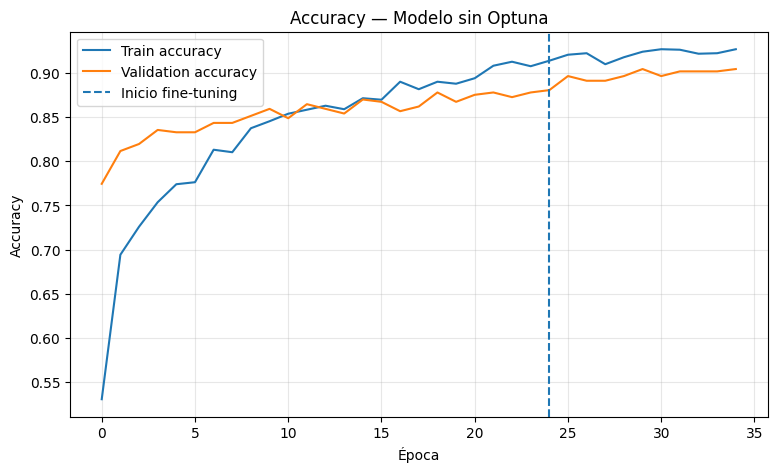

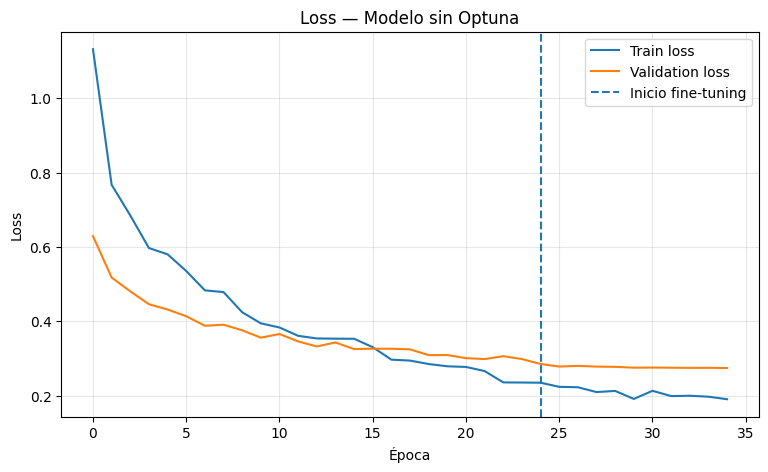

In [48]:
# 21. Curvas de entrenamiento: modelo sin Optuna

def unir_historiales(history_fase1, history_fase2):
    resultado = {}

    for metrica in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        resultado[metrica] = (
            history_fase1.history[metrica]
            + history_fase2.history[metrica]
        )

    resultado["inicio_fine_tuning"] = len(
        history_fase1.history["accuracy"]
    )

    return resultado

hist_base = unir_historiales(
    history_base_fase1,
    history_base_fase2
)

plt.figure(figsize=(9, 5))
plt.plot(hist_base["accuracy"], label="Train accuracy")
plt.plot(hist_base["val_accuracy"], label="Validation accuracy")
plt.axvline(
    hist_base["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Accuracy — Modelo sin Optuna")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist_base["loss"], label="Train loss")
plt.plot(hist_base["val_loss"], label="Validation loss")
plt.axvline(
    hist_base["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Loss — Modelo sin Optuna")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


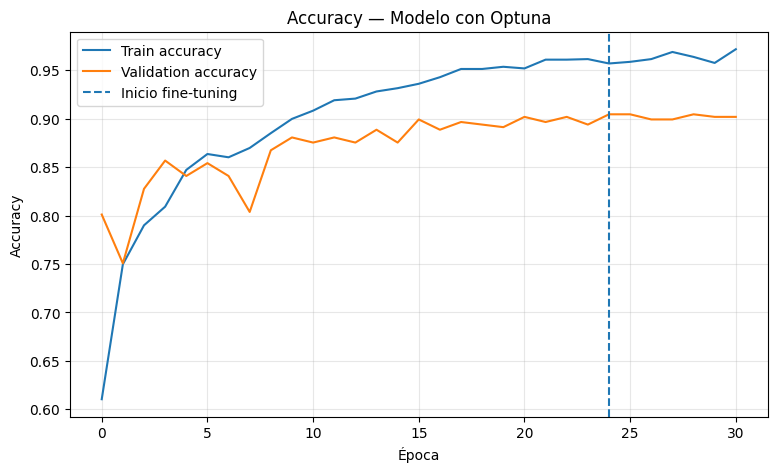

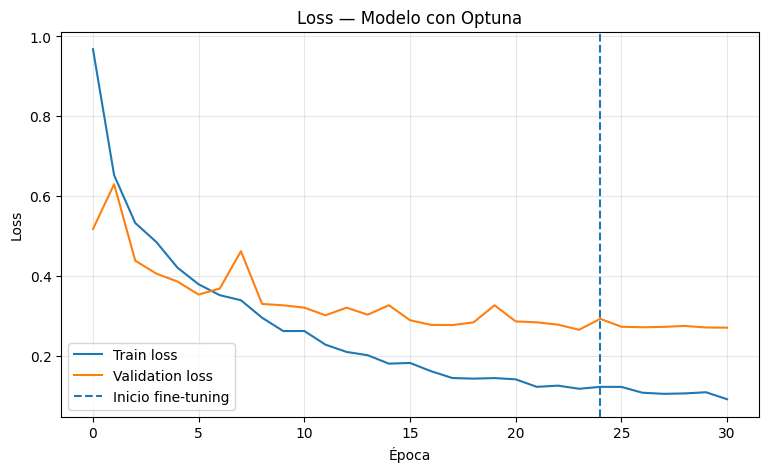

In [49]:
# 22. Curvas de entrenamiento: modelo con Optuna

hist_optuna = unir_historiales(
    history_optuna_fase1,
    history_optuna_fase2
)

plt.figure(figsize=(9, 5))
plt.plot(hist_optuna["accuracy"], label="Train accuracy")
plt.plot(hist_optuna["val_accuracy"], label="Validation accuracy")
plt.axvline(
    hist_optuna["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Accuracy — Modelo con Optuna")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist_optuna["loss"], label="Train loss")
plt.plot(hist_optuna["val_loss"], label="Validation loss")
plt.axvline(
    hist_optuna["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Loss — Modelo con Optuna")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [50]:
# 23. Reportes de clasificación

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — SIN OPTUNA")
print("=" * 70)
print(
    classification_report(
        y_true,
        y_pred_base,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — CON OPTUNA")
print("=" * 70)
print(
    classification_report(
        y_true,
        y_pred_optuna,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)


REPORTE DE CLASIFICACIÓN — SIN OPTUNA
              precision    recall  f1-score   support

    amarillo     0.7895    0.8889    0.8362       135
        azul     0.9600    0.9536    0.9568       151
        gris     0.6667    0.7273    0.6957        22
       verde     0.8448    0.6447    0.7313        76

    accuracy                         0.8568       384
   macro avg     0.8152    0.8036    0.8050       384
weighted avg     0.8604    0.8568    0.8548       384

REPORTE DE CLASIFICACIÓN — CON OPTUNA
              precision    recall  f1-score   support

    amarillo     0.7590    0.9333    0.8372       135
        azul     0.9733    0.9669    0.9701       151
        gris     0.7895    0.6818    0.7317        22
       verde     0.8776    0.5658    0.6880        76

    accuracy                         0.8594       384
   macro avg     0.8498    0.7870    0.8068       384
weighted avg     0.8685    0.8594    0.8539       384



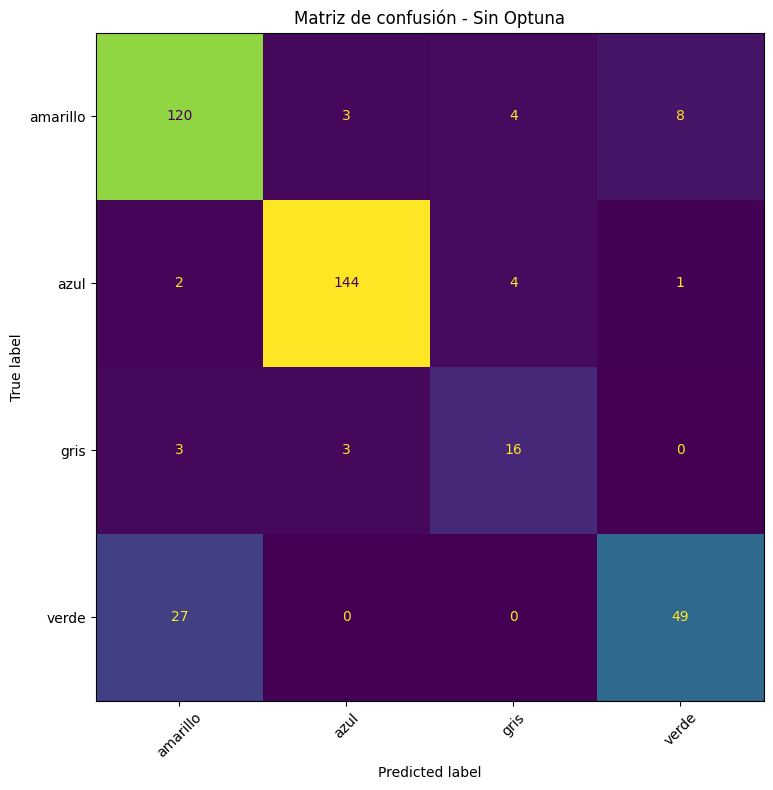

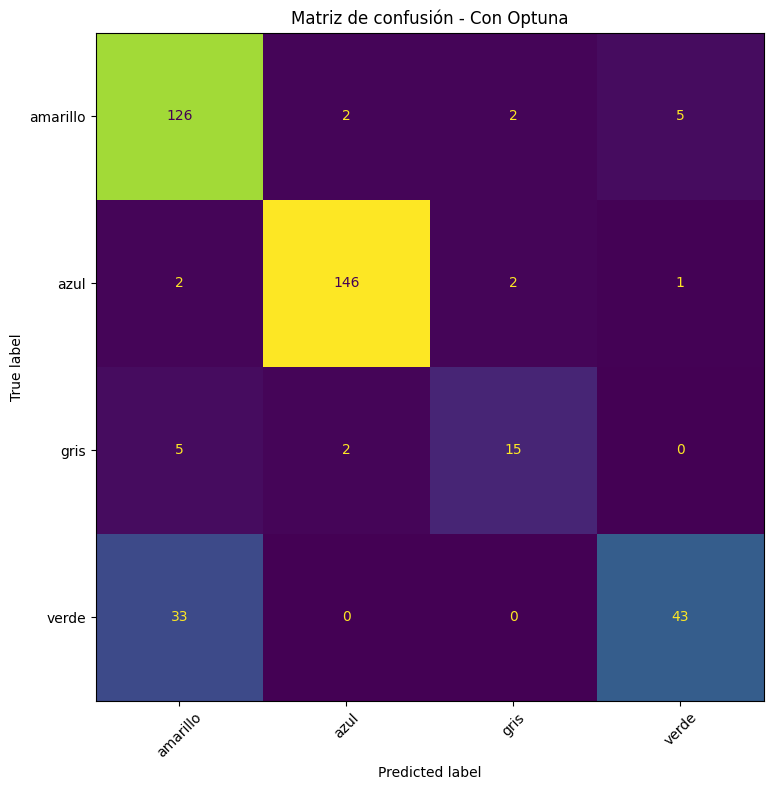

In [52]:
# 24. Matrices de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_base = confusion_matrix(y_true, y_pred_base)
cm_optuna = confusion_matrix(y_true, y_pred_optuna)

# Matriz SIN Optuna
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Matriz de confusión - Sin Optuna")
plt.tight_layout()
plt.show()


# Matriz CON Optuna
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Matriz de confusión - Con Optuna")
plt.tight_layout()
plt.show()

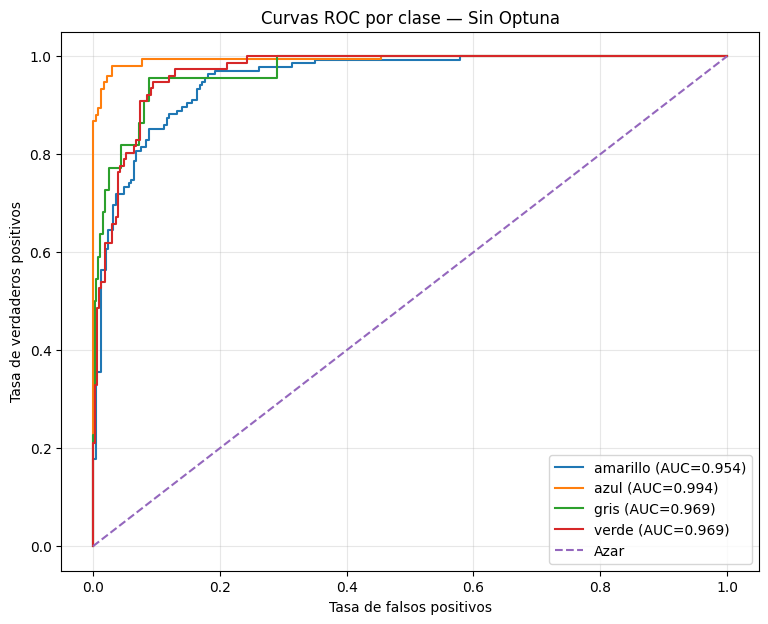

In [53]:
# 25. Curvas ROC por clase — Sin Optuna

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(N_CLASSES)
)

def graficar_roc_por_clase(y_bin, y_prob, titulo):
    plt.figure(figsize=(9, 7))

    aucs = {}

    for i, clase in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(
            y_bin[:, i],
            y_prob[:, i]
        )
        roc_auc = auc(fpr, tpr)
        aucs[clase] = roc_auc

        plt.plot(
            fpr,
            tpr,
            label=f"{clase} (AUC={roc_auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return aucs

auc_clases_base = graficar_roc_por_clase(
    y_true_bin,
    y_prob_base,
    "Curvas ROC por clase — Sin Optuna"
)


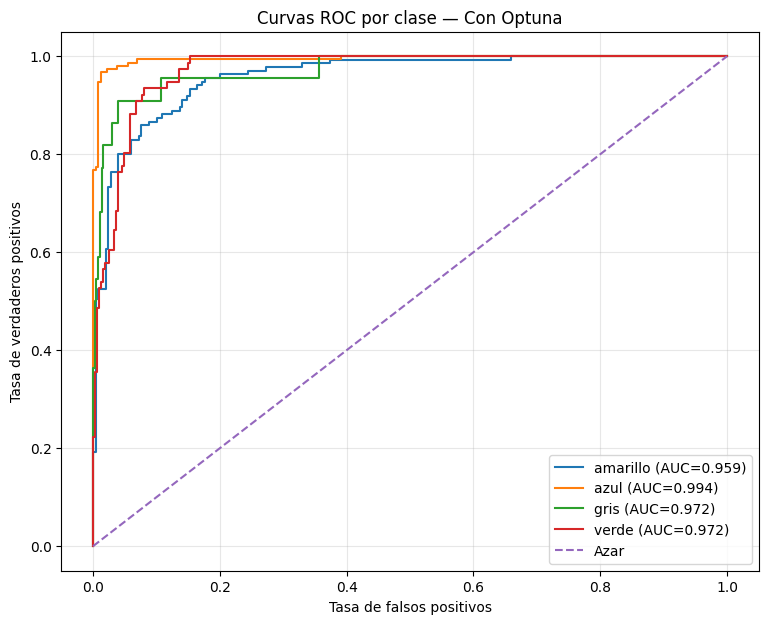

In [54]:
# 26. Curvas ROC por clase — Con Optuna

auc_clases_optuna = graficar_roc_por_clase(
    y_true_bin,
    y_prob_optuna,
    "Curvas ROC por clase — Con Optuna"
)


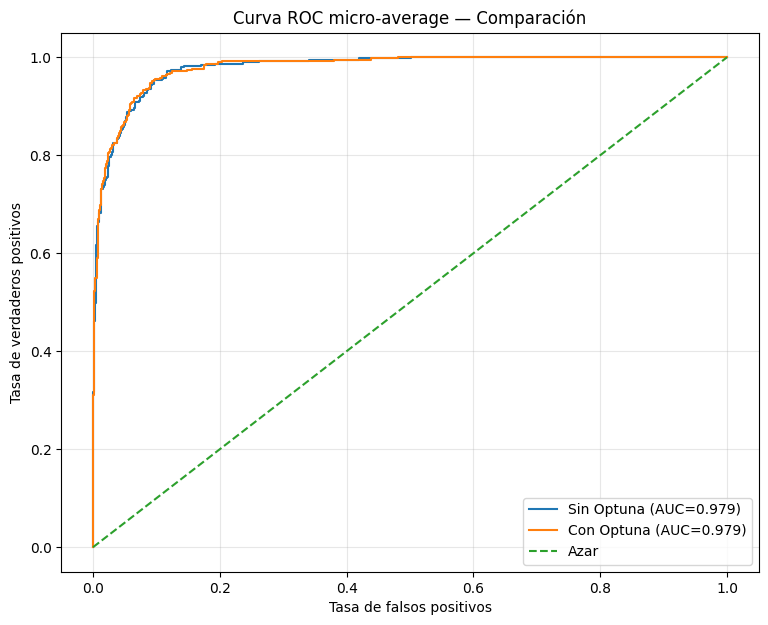

In [55]:
# 27. Comparación ROC micro-average

fpr_base_micro, tpr_base_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_prob_base.ravel()
)

fpr_optuna_micro, tpr_optuna_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_prob_optuna.ravel()
)

auc_base_micro = auc(
    fpr_base_micro,
    tpr_base_micro
)

auc_optuna_micro = auc(
    fpr_optuna_micro,
    tpr_optuna_micro
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_base_micro,
    tpr_base_micro,
    label=f"Sin Optuna (AUC={auc_base_micro:.3f})"
)

plt.plot(
    fpr_optuna_micro,
    tpr_optuna_micro,
    label=f"Con Optuna (AUC={auc_optuna_micro:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC micro-average — Comparación")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


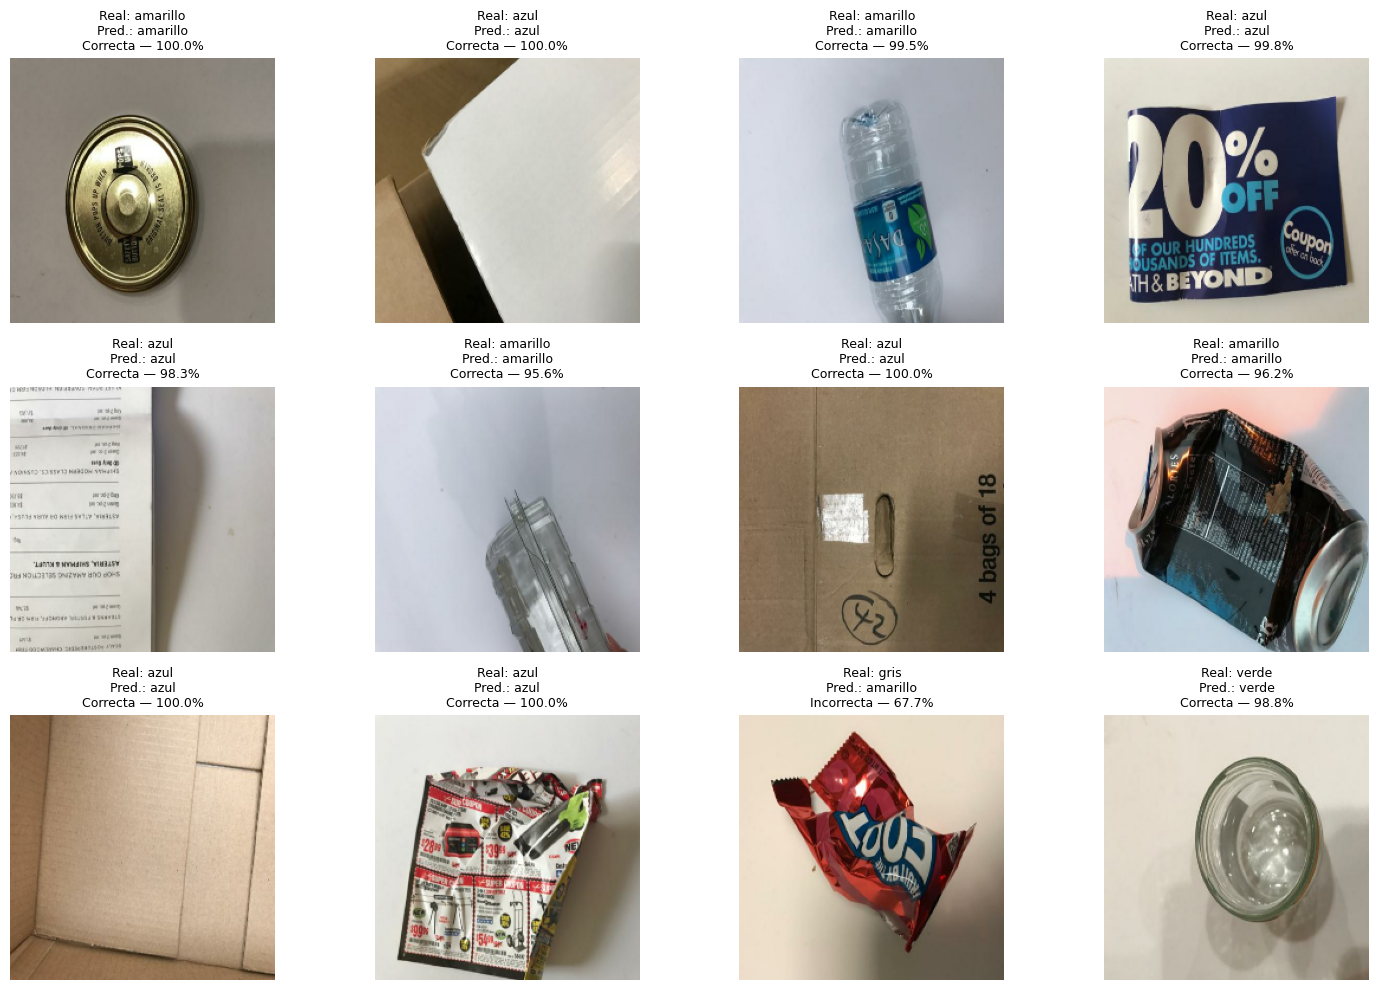

In [56]:
# 28. Predicciones aleatorias del modelo con Optuna

images_all = []
labels_all = []

for images, labels in test_ds:
    images_all.append(images.numpy())
    labels_all.append(labels.numpy())

images_all = np.concatenate(images_all)
labels_all = np.concatenate(labels_all)

rng = np.random.default_rng(SEED)
indices = rng.choice(
    len(images_all),
    size=min(12, len(images_all)),
    replace=False
)

selected_images = images_all[indices]
selected_labels = labels_all[indices]

selected_prob = model_optuna.predict(
    selected_images,
    verbose=0
)

plt.figure(figsize=(15, 10))

for i in range(len(indices)):
    true_index = int(np.argmax(selected_labels[i]))
    pred_index = int(np.argmax(selected_prob[i]))
    confidence = float(selected_prob[i][pred_index])

    plt.subplot(3, 4, i + 1)
    plt.imshow(selected_images[i].astype("uint8"))

    estado = "Correcta" if true_index == pred_index else "Incorrecta"

    plt.title(
        f"Real: {CLASSES[true_index]}\n"
        f"Pred.: {CLASSES[pred_index]}\n"
        f"{estado} — {confidence:.1%}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [59]:
# 27. Resumen final

print("=" * 76)
print("RESUMEN FINAL - TRASHNET JERÁRQUICO POR CONTENEDOR")
print("=" * 76)

print("\nDATASET")
print("- Train: 1766 imágenes")
print("- Validation: 377 imágenes")
print("- Test: 384 imágenes")
print(f"- Clases finales: {N_CLASSES}")

print("\nCLASES / CONTENEDORES")
for i, clase in enumerate(CLASSES):
    print(f"- {i}: {clase}")

print("\nAGRUPACIÓN UTILIZADA")
print("- Azul: papel + cartón")
print("- Amarillo: plástico + metal")
print("- Verde: vidrio")
print("- Gris: basura")


print("\nMODELO BASE - SIN OPTUNA")
print(f"- Accuracy: {metricas_base['Accuracy'] * 100:.2f}%")
print(f"- Precision macro: {metricas_base['Precision macro']:.4f}")
print(f"- Recall macro: {metricas_base['Recall macro']:.4f}")
print(f"- F1 macro: {metricas_base['F1 macro']:.4f}")
print(f"- ROC AUC macro OVR: {metricas_base['ROC AUC macro OVR']:.4f}")


print("\nOPTUNA")
print(f"- Mejor trial: {study.best_trial.number}")
print(f"- Mejor val_accuracy durante búsqueda: {study.best_value * 100:.2f}%")

print("\nMejores hiperparámetros encontrados:")
for parametro, valor in study.best_params.items():
    print(f"- {parametro}: {valor}")


print("\nMODELO OPTIMIZADO - CON OPTUNA")
print(f"- Accuracy: {metricas_optuna['Accuracy'] * 100:.2f}%")
print(f"- Precision macro: {metricas_optuna['Precision macro']:.4f}")
print(f"- Recall macro: {metricas_optuna['Recall macro']:.4f}")
print(f"- F1 macro: {metricas_optuna['F1 macro']:.4f}")
print(f"- ROC AUC macro OVR: {metricas_optuna['ROC AUC macro OVR']:.4f}")


print("\nCOMPARACIÓN FINAL")

diferencia_accuracy = (
    metricas_optuna["Accuracy"] - metricas_base["Accuracy"]
) * 100

print(f"- Accuracy sin Optuna: {metricas_base['Accuracy'] * 100:.2f}%")
print(f"- Accuracy con Optuna: {metricas_optuna['Accuracy'] * 100:.2f}%")
print(f"- Diferencia: {diferencia_accuracy:+.2f} puntos porcentuales")


print("\n" + "=" * 76)
print("FIN DEL RESUMEN")
print("=" * 76)

RESUMEN FINAL - TRASHNET JERÁRQUICO POR CONTENEDOR

DATASET
- Train: 1766 imágenes
- Validation: 377 imágenes
- Test: 384 imágenes
- Clases finales: 4

CLASES / CONTENEDORES
- 0: amarillo
- 1: azul
- 2: gris
- 3: verde

AGRUPACIÓN UTILIZADA
- Azul: papel + cartón
- Amarillo: plástico + metal
- Verde: vidrio
- Gris: basura

MODELO BASE - SIN OPTUNA
- Accuracy: 85.68%
- Precision macro: 0.8152
- Recall macro: 0.8036
- F1 macro: 0.8050
- ROC AUC macro OVR: 0.9716

OPTUNA
- Mejor trial: 9
- Mejor val_accuracy durante búsqueda: 88.33%

Mejores hiperparámetros encontrados:
- dense_units: 256
- dropout_rate: 0.2
- learning_rate: 0.0004021554526690286
- optimizer: rmsprop

MODELO OPTIMIZADO - CON OPTUNA
- Accuracy: 85.94%
- Precision macro: 0.8498
- Recall macro: 0.7870
- F1 macro: 0.8068
- ROC AUC macro OVR: 0.9741

COMPARACIÓN FINAL
- Accuracy sin Optuna: 85.68%
- Accuracy con Optuna: 85.94%
- Diferencia: +0.26 puntos porcentuales

FIN DEL RESUMEN


## Interpretación final

La predicción de este modelo corresponde al **contenedor recomendado** y no al material original. El reagrupamiento usado es:

| Material original | Contenedor |
|---|---|
| Plástico | Amarillo |
| Papel | Azul |
| Cartón | Azul |
| Vidrio | Verde |
| Metal | Amarillo |
| Trash / rechazo | Gris |

Así, por ejemplo, una imagen de `paper` y una de `cardboard` tienen la misma etiqueta final: `azul`.